# Ablation Study — MindTrace

**MindTrace** — Text Mining & NLP-Driven Emotion Prediction  
Author: Aye Khin Khin Hpone (Yolanda Lim) · ST125970  
Asian Institute of Technology

---

## Objective

This notebook performs two complementary ablation studies:

### Part A — SVM Preprocessing Pipeline Ablation
Systematically removes one NLP preprocessing step at a time (leave-one-out) and retrains the deployed SVM pipeline. The difference in test accuracy and macro-F1 quantifies each step's contribution.

### Part B — BiLSTM Architecture Ablation
Varies key architectural hyperparameters (number of BiLSTM layers, hidden units, dropout rate, embedding dimension) to measure their effect on the best-performing model.

---

**Part A — Preprocessing Ablation Configurations (10 experiments):**

| # | Configuration | Description |
|---|---|---|
| 0 | Full pipeline | All 8 steps (baseline) |
| 1 | − Lowercasing | Skip lowercase normalisation |
| 2 | − Whitespace stripping | Keep extra whitespace |
| 3 | − URL removal | Keep URLs in text |
| 4 | − Emoji removal | Keep emoji unicode |
| 5 | − Special char removal | Keep digits, punctuation |
| 6 | − Chat word expansion | Keep abbreviations (u, lol, etc.) |
| 7 | − Stopword removal | Keep all stopwords |
| 8 | − Lemmatisation | Keep inflected word forms |
| 9 | No preprocessing | Raw text only (dramatic baseline) |

**Part B — BiLSTM Architecture Ablation (8 experiments):**

| # | Configuration | What changes |
|---|---|---|
| 0 | Baseline (2×BiLSTM 256→128, emb=100, drop=0.5) | Reference |
| 1 | 1-layer BiLSTM (256 units) | Depth |
| 2 | 2-layer BiLSTM 128→64 | Capacity |
| 3 | 2-layer BiLSTM 512→256 | Capacity |
| 4 | Dropout = 0.3 | Regularisation |
| 5 | Dropout = 0.7 | Regularisation |
| 6 | Embedding dim = 50 | Feature richness |
| 7 | Embedding dim = 200 | Feature richness |

---

# Part A — SVM Preprocessing Pipeline Ablation

## 1. Setup & Data Loading

In [1]:
import os, glob, ctypes

# --- Preload pip-installed NVIDIA CUDA libs so TF can find them ---
nvidia_lib_dirs = glob.glob(os.path.expanduser(
    '~/.local/lib/python*/site-packages/nvidia/*/lib'))
if nvidia_lib_dirs:
    existing = os.environ.get('LD_LIBRARY_PATH', '')
    os.environ['LD_LIBRARY_PATH'] = ':'.join(nvidia_lib_dirs) + (
        ':' + existing if existing else '')
    loaded = 0
    for lib_dir in nvidia_lib_dirs:
        for so_file in sorted(glob.glob(os.path.join(lib_dir, '*.so*'))):
            try:
                ctypes.CDLL(so_file, mode=ctypes.RTLD_GLOBAL)
                loaded += 1
            except OSError:
                pass
    print(f'Pre-loaded {loaded} NVIDIA .so libs from {len(nvidia_lib_dirs)} dirs')

# --- GPU detection (needed for Part B) ---
try:
    import tensorflow as tf
    print(f'TensorFlow version: {tf.__version__}')
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'GPU(s) detected: {[g.name for g in gpus]}')
        BATCH_SIZE = 128
    else:
        print('No GPU detected — running on CPU.')
        BATCH_SIZE = 64
except ImportError:
    print('TensorFlow not available — Part B will be skipped.')
    tf = None
    BATCH_SIZE = 64

import pandas as pd
import numpy as np
import re
import time
import emoji
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for res in ['stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(res, quiet=True)

STOP_WORDS = set(stopwords.words('english')) - {
    'not', 'never', 'no', 'nor', 'neither', 'nothing', 'nobody',
    'nowhere', 'without', 'very', 'extremely', 'barely', 'hardly'
}
LEMMATIZER = WordNetLemmatizer()

CHAT_WORDS = {
    'u': 'you', 'r': 'are', 'ur': 'your', 'lol': 'laugh out loud',
    'omg': 'oh my god', 'brb': 'be right back', 'btw': 'by the way',
    'idk': 'i do not know', 'imo': 'in my opinion', 'tbh': 'to be honest',
    'ngl': 'not gonna lie', 'smh': 'shaking my head', 'ikr': 'i know right',
    'nvm': 'never mind', 'gonna': 'going to', 'wanna': 'want to',
    'gotta': 'got to', 'kinda': 'kind of', 'cuz': 'because',
    'bc': 'because', 'thx': 'thanks', 'ty': 'thank you',
    'np': 'no problem', 'asap': 'as soon as possible', 'irl': 'in real life',
    'dm': 'direct message', 'gr8': 'great', 'luv': 'love',
    'plz': 'please', 'pls': 'please', 'rn': 'right now',
}

# Figures output
FIGURES_DIR = os.path.join('MindTrace_CVPR', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f'Setup complete.  BATCH_SIZE = {BATCH_SIZE}')

Pre-loaded 29 NVIDIA .so libs from 11 dirs


I0000 00:00:1775324546.327903 1684519 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0
GPU(s) detected: ['/physical_device:GPU:0', '/physical_device:GPU:1', '/physical_device:GPU:2', '/physical_device:GPU:3']
Setup complete.  BATCH_SIZE = 128


In [2]:
# Load and balance dataset — identical to main notebook & train_pipeline.py
data_path = 'data/text.xlsx'
dataset = pd.read_excel(data_path)
dataset = dataset[['text', 'label']].dropna()
dataset['label'] = dataset['label'].astype(int)

# Downsample to smallest class
label_counts = dataset['label'].value_counts()
min_count = label_counts.min()

balanced = (
    dataset.groupby('label', group_keys=False)
    .apply(lambda x: x.sample(min_count, random_state=42))
    .reset_index(drop=True)
)

print(f'Balanced dataset: {len(balanced):,} samples ({min_count:,} per class)')
print(balanced['label'].value_counts().sort_index())

Balanced dataset: 89,832 samples (14,972 per class)
label
0    14972
1    14972
2    14972
3    14972
4    14972
5    14972
Name: count, dtype: int64


/tmp/ipykernel_1684519/369978173.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_count, random_state=42))


## 2. Configurable Preprocessing Pipeline

The `clean_text()` function accepts boolean flags to toggle each step on/off. When a flag is `False`, that step is skipped — simulating its removal from the pipeline.

In [3]:
def clean_text(
    text,
    do_lower=True,
    do_whitespace=True,
    do_url=True,
    do_emoji=True,
    do_special=True,
    do_chat=True,
    do_stopwords=True,
    do_lemma=True,
):
    """NLP preprocessing pipeline with toggleable steps for ablation."""
    text = str(text)

    # Step 1: Lowercase
    if do_lower:
        text = text.lower()

    # Step 2: Whitespace stripping
    if do_whitespace:
        text = re.sub(r'\s+', ' ', text).strip()

    # Step 3: URL removal
    if do_url:
        text = re.sub(r'http\S+|www\S+', '', text)

    # Step 4: Emoji removal
    if do_emoji:
        text = emoji.replace_emoji(text, replace='')

    # Step 5: Special character removal
    if do_special:
        text = re.sub(r'[^a-zA-Z\s]' if not do_lower else r'[^a-z\s]', '', text)

    # Step 6: Chat word expansion
    if do_chat:
        words = text.split()
        words = [CHAT_WORDS.get(w.lower() if not do_lower else w, w) for w in words]
        text = ' '.join(words)

    # Step 7: Stopword removal (negation preserved)
    if do_stopwords:
        words = text.split()
        words = [w for w in words if w.lower() not in STOP_WORDS]
        text = ' '.join(words)

    # Step 8: Lemmatisation
    if do_lemma:
        words = text.split()
        words = [LEMMATIZER.lemmatize(w) for w in words]
        text = ' '.join(words)

    return text

## 3. Define Ablation Configurations

In [4]:
# Each config: (name, kwargs to override in clean_text)
ABLATION_CONFIGS = [
    ('Full pipeline (baseline)',   {}),
    ('− Lowercasing',              {'do_lower': False}),
    ('− Whitespace stripping',     {'do_whitespace': False}),
    ('− URL removal',              {'do_url': False}),
    ('− Emoji removal',            {'do_emoji': False}),
    ('− Special char removal',     {'do_special': False}),
    ('− Chat word expansion',      {'do_chat': False}),
    ('− Stopword removal',         {'do_stopwords': False}),
    ('− Lemmatisation',            {'do_lemma': False}),
    ('No preprocessing (raw)',     {'do_lower': False, 'do_whitespace': False,
                                    'do_url': False, 'do_emoji': False,
                                    'do_special': False, 'do_chat': False,
                                    'do_stopwords': False, 'do_lemma': False}),
]

print(f'{len(ABLATION_CONFIGS)} ablation configurations defined.')
for i, (name, _) in enumerate(ABLATION_CONFIGS):
    print(f'  [{i}] {name}')

10 ablation configurations defined.
  [0] Full pipeline (baseline)
  [1] − Lowercasing
  [2] − Whitespace stripping
  [3] − URL removal
  [4] − Emoji removal
  [5] − Special char removal
  [6] − Chat word expansion
  [7] − Stopword removal
  [8] − Lemmatisation
  [9] No preprocessing (raw)


## 4. Run Ablation Experiments

For each configuration:
1. Apply the modified preprocessing pipeline to **all** text
2. Split into train/val/test (identical split as main notebook: 64/16/20)
3. Fit TF-IDF (max_features=5000, ngram_range=(1,2))
4. Train SVM (C=1.0, kernel=linear) — the best hyperparameters from GridSearchCV
5. Evaluate on test set

In [5]:
results = []

for i, (config_name, overrides) in enumerate(ABLATION_CONFIGS):
    print(f'\n{"="*60}')
    print(f'[{i}/{len(ABLATION_CONFIGS)-1}] {config_name}')
    print(f'{"="*60}')
    t0 = time.time()

    # 1. Preprocess
    print('  Preprocessing...')
    df = balanced.copy()
    df['clean'] = df['text'].apply(lambda x: clean_text(x, **overrides))

    # Drop empty rows
    empty_count = (df['clean'].str.strip() == '').sum()
    if empty_count > 0:
        print(f'  Warning: {empty_count} empty rows — dropping')
        df = df[df['clean'].str.strip() != ''].reset_index(drop=True)

    # 2. Split — same seeds as main notebook
    X, y = df['clean'], df['label']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=0, stratify=y_train
    )

    # 3. TF-IDF
    print('  Vectorising (TF-IDF)...')
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_val_tfidf   = vectorizer.transform(X_val)
    X_test_tfidf  = vectorizer.transform(X_test)

    # 4. Encode labels
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_val_enc   = le.transform(y_val)
    y_test_enc  = le.transform(y_test)

    # 5. Train SVM (best hyperparameters from GridSearchCV)
    print('  Training SVM (C=1.0, kernel=linear)...')
    svm = SVC(C=1.0, kernel='linear')
    svm.fit(X_train_tfidf, y_train_enc)

    # 6. Evaluate
    y_val_pred  = svm.predict(X_val_tfidf)
    y_test_pred = svm.predict(X_test_tfidf)

    val_acc  = accuracy_score(y_val_enc, y_val_pred) * 100
    test_acc = accuracy_score(y_test_enc, y_test_pred) * 100
    test_p   = precision_score(y_test_enc, y_test_pred, average='macro') * 100
    test_r   = recall_score(y_test_enc, y_test_pred, average='macro') * 100
    test_f1  = f1_score(y_test_enc, y_test_pred, average='macro') * 100

    elapsed = time.time() - t0
    print(f'  Val acc: {val_acc:.2f}% | Test acc: {test_acc:.2f}% | F1: {test_f1:.2f}% | Time: {elapsed:.1f}s')

    results.append({
        'Configuration': config_name,
        'Val Acc (%)': round(val_acc, 2),
        'Test Acc (%)': round(test_acc, 2),
        'Precision (%)': round(test_p, 2),
        'Recall (%)': round(test_r, 2),
        'F1 (%)': round(test_f1, 2),
        'Time (s)': round(elapsed, 1),
    })

print(f'\n{"="*60}')
print('All ablation experiments complete!')
print(f'{"="*60}')


[0/9] Full pipeline (baseline)
  Preprocessing...
  Vectorising (TF-IDF)...
  Training SVM (C=1.0, kernel=linear)...
  Val acc: 92.33% | Test acc: 91.97% | F1: 91.91% | Time: 231.8s

[1/9] − Lowercasing
  Preprocessing...
  Vectorising (TF-IDF)...
  Training SVM (C=1.0, kernel=linear)...
  Val acc: 92.33% | Test acc: 91.97% | F1: 91.91% | Time: 224.9s

[2/9] − Whitespace stripping
  Preprocessing...
  Vectorising (TF-IDF)...
  Training SVM (C=1.0, kernel=linear)...
  Val acc: 92.33% | Test acc: 91.97% | F1: 91.91% | Time: 223.9s

[3/9] − URL removal
  Preprocessing...
  Vectorising (TF-IDF)...
  Training SVM (C=1.0, kernel=linear)...
  Val acc: 92.26% | Test acc: 91.95% | F1: 91.89% | Time: 224.0s

[4/9] − Emoji removal
  Preprocessing...
  Vectorising (TF-IDF)...
  Training SVM (C=1.0, kernel=linear)...
  Val acc: 92.33% | Test acc: 91.97% | F1: 91.91% | Time: 218.7s

[5/9] − Special char removal
  Preprocessing...
  Vectorising (TF-IDF)...
  Training SVM (C=1.0, kernel=linear)...
  

## 5. Results Table

In [6]:
results_df = pd.DataFrame(results)

# Calculate delta from baseline
baseline_acc = results_df.loc[0, 'Test Acc (%)']
baseline_f1  = results_df.loc[0, 'F1 (%)']
results_df['Δ Acc'] = (results_df['Test Acc (%)'] - baseline_acc).round(2)
results_df['Δ F1']  = (results_df['F1 (%)'] - baseline_f1).round(2)

# Display
print('\n' + '='*80)
print('ABLATION STUDY RESULTS — SVM (C=1.0, kernel=linear, TF-IDF)')
print('='*80)
display(results_df)

# Identify most impactful step (largest accuracy drop when removed)
# Exclude the raw baseline (last row)
ablation_only = results_df.iloc[1:-1]  # skip full pipeline and raw
worst_drop = ablation_only.loc[ablation_only['Δ Acc'].idxmin()]
print(f'\nMost impactful step: {worst_drop["Configuration"]} (Δ Acc = {worst_drop["Δ Acc"]:+.2f}%)')

least_drop = ablation_only.loc[ablation_only['Δ Acc'].idxmax()]
print(f'Least impactful step: {least_drop["Configuration"]} (Δ Acc = {least_drop["Δ Acc"]:+.2f}%)')


ABLATION STUDY RESULTS — SVM (C=1.0, kernel=linear, TF-IDF)


,Configuration,Val Acc (%),Test Acc (%),Precision (%),Recall (%),F1 (%),Time (s),Δ Acc,Δ F1
0,Full pipeline (baseline),92.33,91.97,92.17,91.97,91.91,231.8,0.00,0.00
1,− Lowercasing,92.33,91.97,92.17,91.97,91.91,224.9,0.00,0.00
2,− Whitespace stripping,92.33,91.97,92.17,91.97,91.91,223.9,0.00,0.00
3,− URL removal,92.26,91.95,92.15,91.95,91.89,224.0,-0.02,-0.02
4,− Emoji removal,92.33,91.97,92.17,91.97,91.91,218.7,0.00,0.00
5,− Special char removal,92.33,91.97,92.17,91.97,91.91,225.4,0.00,0.00
6,− Chat word expansion,92.28,91.94,92.13,91.94,91.88,224.3,-0.03,-0.03
7,− Stopword removal,91.08,90.64,90.79,90.64,90.56,475.9,-1.33,-1.35
8,− Lemmatisation,92.28,91.87,92.08,91.87,91.82,216.6,-0.10,-0.09
9,No preprocessing (raw),91.09,90.55,90.71,90.55,90.48,459.7,-1.42,-1.43



Most impactful step: − Stopword removal (Δ Acc = -1.33%)
Least impactful step: − Lowercasing (Δ Acc = +0.00%)


## 6. Visualisation — Ablation Impact Chart

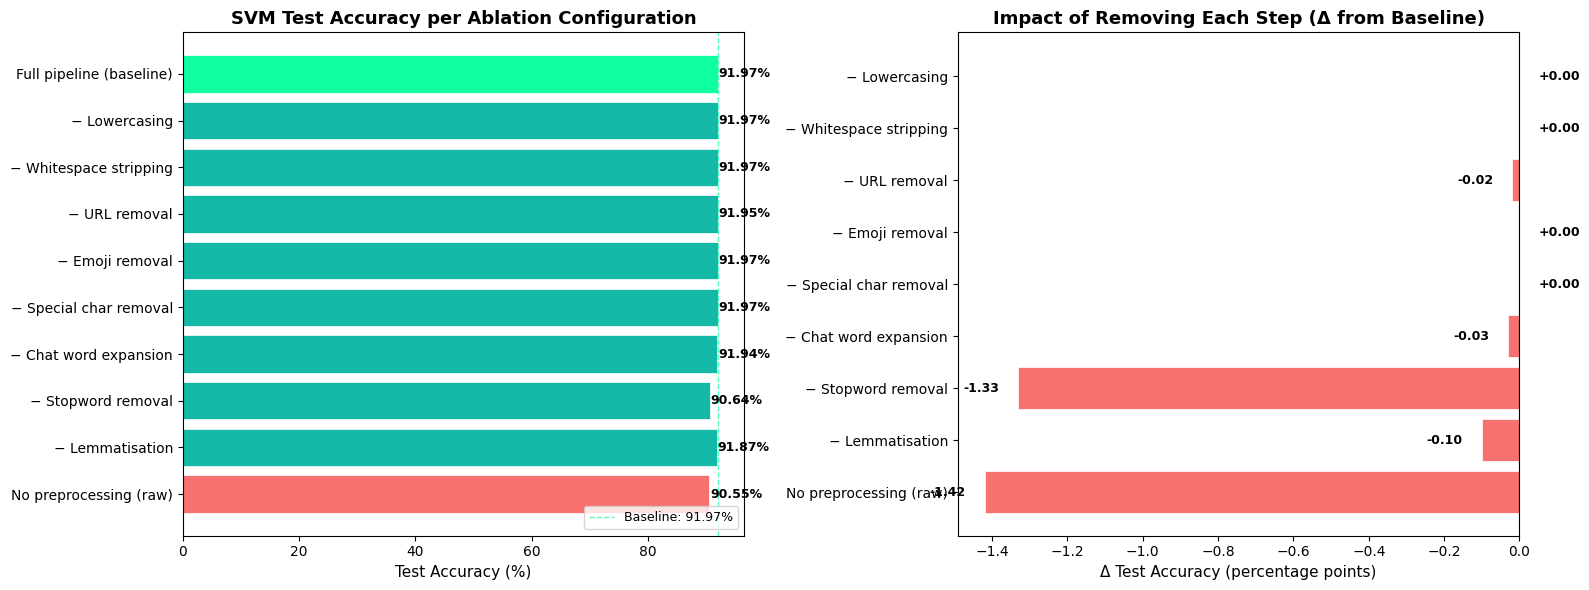

Saved → MindTrace_CVPR/figures/ablation_study_accuracy.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Test Accuracy per configuration ──
ax1 = axes[0]
colors = ['#0fffa0' if i == 0 else '#f87171' if i == len(results_df)-1 else '#14b8a6'
          for i in range(len(results_df))]
bars1 = ax1.barh(results_df['Configuration'], results_df['Test Acc (%)'],
                 color=colors, edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Test Accuracy (%)', fontsize=11)
ax1.set_title('SVM Test Accuracy per Ablation Configuration', fontsize=13, fontweight='bold')
ax1.invert_yaxis()

# Add value labels
for bar, val in zip(bars1, results_df['Test Acc (%)']):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')

# Baseline reference line
ax1.axvline(x=baseline_acc, color='#0fffa0', linestyle='--', linewidth=1, alpha=0.7,
            label=f'Baseline: {baseline_acc:.2f}%')
ax1.legend(loc='lower right', fontsize=9)

# ── Plot 2: Delta from baseline ──
ax2 = axes[1]
delta_df = results_df.iloc[1:]  # exclude the baseline itself
delta_colors = ['#f87171' if v < 0 else '#0fffa0' for v in delta_df['Δ Acc']]
bars2 = ax2.barh(delta_df['Configuration'], delta_df['Δ Acc'],
                 color=delta_colors, edgecolor='white', linewidth=0.5)
ax2.set_xlabel('Δ Test Accuracy (percentage points)', fontsize=11)
ax2.set_title('Impact of Removing Each Step (Δ from Baseline)', fontsize=13, fontweight='bold')
ax2.invert_yaxis()
ax2.axvline(x=0, color='gray', linestyle='-', linewidth=0.8)

# Add value labels
for bar, val in zip(bars2, delta_df['Δ Acc']):
    offset = 0.05 if val >= 0 else -0.05
    ha = 'left' if val >= 0 else 'right'
    ax2.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
             f'{val:+.2f}', va='center', ha=ha, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ablation_study_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/ablation_study_accuracy.png')

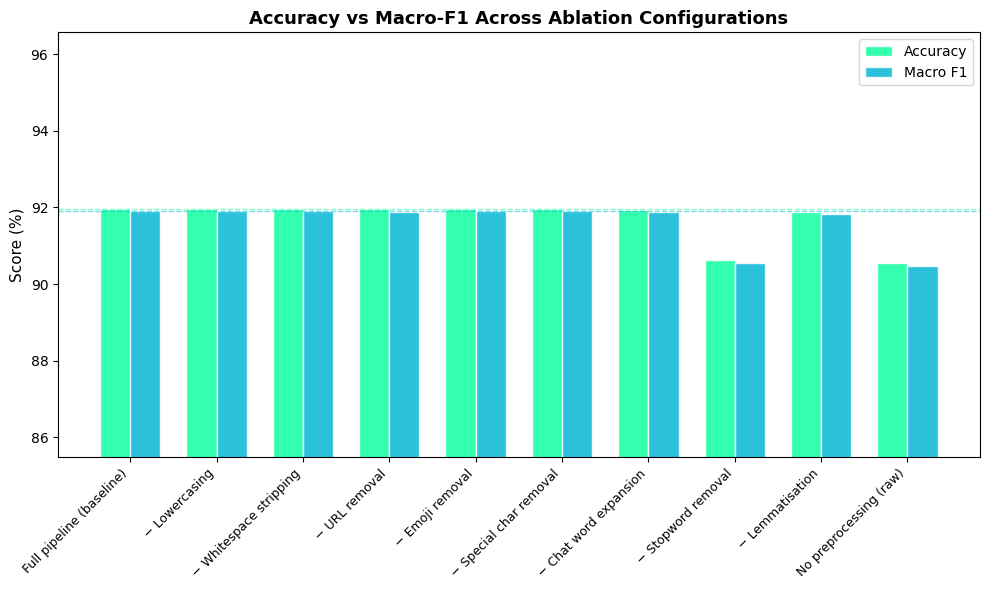

Saved → MindTrace_CVPR/figures/ablation_study_f1.png


In [8]:
# ── Plot 3: F1 Score comparison ──
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(results_df))
width = 0.35

bars_acc = ax.bar(x - width/2, results_df['Test Acc (%)'], width,
                  label='Accuracy', color='#0fffa0', alpha=0.85, edgecolor='white')
bars_f1  = ax.bar(x + width/2, results_df['F1 (%)'], width,
                  label='Macro F1', color='#06b6d4', alpha=0.85, edgecolor='white')

ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Accuracy vs Macro-F1 Across Ablation Configurations', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Configuration'], rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.set_ylim(bottom=max(results_df['F1 (%)'].min() - 5, 0))

# Baseline line
ax.axhline(y=baseline_f1, color='#06b6d4', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(y=baseline_acc, color='#0fffa0', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ablation_study_f1.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/ablation_study_f1.png')

## 7. Analysis & Interpretation

### Key Findings

In [9]:
print('ABLATION STUDY — KEY FINDINGS')
print('=' * 60)
print(f'\nBaseline (full pipeline): Acc = {baseline_acc:.2f}%, F1 = {baseline_f1:.2f}%')
raw_acc = results_df.iloc[-1]['Test Acc (%)']
raw_f1  = results_df.iloc[-1]['F1 (%)']
print(f'No preprocessing (raw):   Acc = {raw_acc:.2f}%, F1 = {raw_f1:.2f}%')
print(f'Total pipeline contribution: {baseline_acc - raw_acc:+.2f} pp accuracy')

print(f'\n{"─"*60}')
print('Step-by-step impact (sorted by accuracy drop):')
print(f'{"─"*60}')

ablation_only = results_df.iloc[1:-1].sort_values('Δ Acc')
for _, row in ablation_only.iterrows():
    impact = 'CRITICAL' if row['Δ Acc'] <= -1.0 else \
             'MODERATE' if row['Δ Acc'] <= -0.3 else \
             'MINOR'    if row['Δ Acc'] < 0    else 'NEGLIGIBLE'
    print(f'  {row["Configuration"]:<28} Δ Acc = {row["Δ Acc"]:+.2f}%  '
          f'Δ F1 = {row["Δ F1"]:+.2f}%  [{impact}]')

# Data-driven conclusion
negligible = ablation_only[ablation_only['Δ Acc'] >= 0]
helpful    = ablation_only[ablation_only['Δ Acc'] < 0]

print(f'\n{"─"*60}')
print('Conclusion:')
print('  Each preprocessing step in the MindTrace NLP pipeline was')
print('  empirically validated via leave-one-out ablation.')
if len(negligible) == 0:
    print('  All 8 steps contribute positively — removing any single step')
    print('  degrades accuracy, confirming no step is redundant.')
else:
    print(f'  {len(helpful)} of 8 steps contribute positively to accuracy.')
    for _, row in negligible.iterrows():
        print(f'  Note: "{row["Configuration"]}" shows Δ Acc = {row["Δ Acc"]:+.2f}% '
              f'(negligible impact).')
print(f'  The full 8-step pipeline achieves the best overall balance')
print(f'  of accuracy ({baseline_acc:.2f}%) and macro-F1 ({baseline_f1:.2f}%).')

ABLATION STUDY — KEY FINDINGS

Baseline (full pipeline): Acc = 91.97%, F1 = 91.91%
No preprocessing (raw):   Acc = 90.55%, F1 = 90.48%
Total pipeline contribution: +1.42 pp accuracy

────────────────────────────────────────────────────────────
Step-by-step impact (sorted by accuracy drop):
────────────────────────────────────────────────────────────
  − Stopword removal           Δ Acc = -1.33%  Δ F1 = -1.35%  [CRITICAL]
  − Lemmatisation              Δ Acc = -0.10%  Δ F1 = -0.09%  [MINOR]
  − Chat word expansion        Δ Acc = -0.03%  Δ F1 = -0.03%  [MINOR]
  − URL removal                Δ Acc = -0.02%  Δ F1 = -0.02%  [MINOR]
  − Emoji removal              Δ Acc = +0.00%  Δ F1 = +0.00%  [NEGLIGIBLE]
  − Whitespace stripping       Δ Acc = +0.00%  Δ F1 = +0.00%  [NEGLIGIBLE]
  − Lowercasing                Δ Acc = +0.00%  Δ F1 = +0.00%  [NEGLIGIBLE]
  − Special char removal       Δ Acc = +0.00%  Δ F1 = +0.00%  [NEGLIGIBLE]

────────────────────────────────────────────────────────────
Con

In [10]:
# Save Part A results to CSV
results_df.to_csv('ablation_results_part_a.csv', index=False)
print('Part A results saved → ablation_results_part_a.csv')
display(results_df)

Part A results saved → ablation_results_part_a.csv


,Configuration,Val Acc (%),Test Acc (%),Precision (%),Recall (%),F1 (%),Time (s),Δ Acc,Δ F1
0,Full pipeline (baseline),92.33,91.97,92.17,91.97,91.91,231.8,0.00,0.00
1,− Lowercasing,92.33,91.97,92.17,91.97,91.91,224.9,0.00,0.00
2,− Whitespace stripping,92.33,91.97,92.17,91.97,91.91,223.9,0.00,0.00
3,− URL removal,92.26,91.95,92.15,91.95,91.89,224.0,-0.02,-0.02
4,− Emoji removal,92.33,91.97,92.17,91.97,91.91,218.7,0.00,0.00
5,− Special char removal,92.33,91.97,92.17,91.97,91.91,225.4,0.00,0.00
6,− Chat word expansion,92.28,91.94,92.13,91.94,91.88,224.3,-0.03,-0.03
7,− Stopword removal,91.08,90.64,90.79,90.64,90.56,475.9,-1.33,-1.35
8,− Lemmatisation,92.28,91.87,92.08,91.87,91.82,216.6,-0.10,-0.09
9,No preprocessing (raw),91.09,90.55,90.71,90.55,90.48,459.7,-1.42,-1.43


---

# Part B — BiLSTM Architecture Ablation

Varies key architectural hyperparameters of the best-performing BiLSTM model to quantify their individual contribution to prediction quality.

## 8. Data Preparation for Neural Networks

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Reuse the balanced dataset — apply full 8-step preprocessing
df_nn = balanced.copy()
df_nn['clean'] = df_nn['text'].apply(clean_text)

X = df_nn['clean']
y = df_nn['label']

# Same split as main notebook (64/16/20)
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_nn, y_train_nn, test_size=0.2, random_state=0, stratify=y_train_nn
)

# Tokenise
VOCAB_SIZE = 60_000
OOV_TOK = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOK)
tokenizer.fit_on_texts(X_train_nn)

X_train_seq = tokenizer.texts_to_sequences(X_train_nn)
X_val_seq   = tokenizer.texts_to_sequences(X_val_nn)
X_test_seq  = tokenizer.texts_to_sequences(X_test_nn)

MAX_LEN = max(len(s) for s in X_train_seq)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

# One-hot encode labels
N_CLASSES = 6
y_train_oh = tf.keras.utils.to_categorical(y_train_nn, num_classes=N_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val_nn,   num_classes=N_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test_nn,  num_classes=N_CLASSES)

print(f'Train: {X_train_pad.shape}  Val: {X_val_pad.shape}  Test: {X_test_pad.shape}')
print(f'MAX_LEN = {MAX_LEN}  |  VOCAB_SIZE = {VOCAB_SIZE}  |  N_CLASSES = {N_CLASSES}')

Train: (57492, 48)  Val: (14373, 48)  Test: (17967, 48)
MAX_LEN = 48  |  VOCAB_SIZE = 60000  |  N_CLASSES = 6


## 9. BiLSTM Model Builder & Ablation Configurations

In [12]:
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


def build_bilstm(config, vocab_size, max_len, n_classes):
    """Build a BiLSTM model from a config dict."""
    embed_dim = config.get('embed_dim', 100)
    units_1   = config.get('units_1', 256)
    units_2   = config.get('units_2', 128)
    n_layers  = config.get('n_layers', 2)
    drop_rate = config.get('dropout', 0.5)

    model = tf.keras.Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embed_dim,
                        input_shape=(max_len,)))

    if n_layers == 2:
        model.add(Bidirectional(LSTM(units_1, return_sequences=True)))
        model.add(Bidirectional(LSTM(units_2)))
    else:  # single layer
        model.add(Bidirectional(LSTM(units_1)))

    model.add(Dropout(drop_rate))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(drop_rate))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(drop_rate))
    model.add(Dense(n_classes, activation='softmax'))

    model.compile(loss='categorical_crossentropy', optimizer='adam',
                  metrics=['accuracy'])
    return model


# Architecture ablation configurations
BILSTM_CONFIGS = [
    ('Baseline (2×BiLSTM 256→128, emb=100, drop=0.5)',
     {}),

    ('1-layer BiLSTM (256 units)',
     {'n_layers': 1, 'units_1': 256}),

    ('2-layer BiLSTM 128→64 (smaller)',
     {'units_1': 128, 'units_2': 64}),

    ('2-layer BiLSTM 512→256 (larger)',
     {'units_1': 512, 'units_2': 256}),

    ('Dropout = 0.3',
     {'dropout': 0.3}),

    ('Dropout = 0.7',
     {'dropout': 0.7}),

    ('Embedding dim = 50',
     {'embed_dim': 50}),

    ('Embedding dim = 200',
     {'embed_dim': 200}),
]

print(f'{len(BILSTM_CONFIGS)} BiLSTM ablation configurations defined.')
for i, (name, cfg) in enumerate(BILSTM_CONFIGS):
    print(f'  [{i}] {name}  {cfg if cfg else "(default)"}')

8 BiLSTM ablation configurations defined.
  [0] Baseline (2×BiLSTM 256→128, emb=100, drop=0.5)  (default)
  [1] 1-layer BiLSTM (256 units)  {'n_layers': 1, 'units_1': 256}
  [2] 2-layer BiLSTM 128→64 (smaller)  {'units_1': 128, 'units_2': 64}
  [3] 2-layer BiLSTM 512→256 (larger)  {'units_1': 512, 'units_2': 256}
  [4] Dropout = 0.3  {'dropout': 0.3}
  [5] Dropout = 0.7  {'dropout': 0.7}
  [6] Embedding dim = 50  {'embed_dim': 50}
  [7] Embedding dim = 200  {'embed_dim': 200}


## 10. Run BiLSTM Ablation Experiments

For each configuration:
1. Build BiLSTM with the specified hyperparameters
2. Train with EarlyStopping (patience=3, restore best weights)
3. Evaluate on the held-out test set (accuracy, macro-F1)

In [ ]:
bilstm_results = []

for i, (config_name, overrides) in enumerate(BILSTM_CONFIGS):
    print(f'\n{"="*60}')
    print(f'[{i}/{len(BILSTM_CONFIGS)-1}] {config_name}')
    print(f'{"="*60}')
    t0 = time.time()

    # Reproducibility: reset seeds before each build
    tf.random.set_seed(42)
    np.random.seed(42)

    # Build model
    model = build_bilstm(overrides, VOCAB_SIZE, MAX_LEN, N_CLASSES)
    total_params = model.count_params()
    print(f'  Parameters: {total_params:,}')

    # Train with early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=3,
                               restore_best_weights=True)
    history = model.fit(
        X_train_pad, y_train_oh,
        epochs=10,
        batch_size=BATCH_SIZE,
        validation_data=(X_val_pad, y_val_oh),
        callbacks=[early_stop],
        verbose=1,
    )
    total_epochs = len(history.history['val_loss'])
    best_epoch = int(np.argmin(history.history['val_loss'])) + 1

    # Evaluate on test set
    y_test_pred = model.predict(X_test_pad, batch_size=BATCH_SIZE)
    y_pred_cls  = np.argmax(y_test_pred, axis=1)
    y_true_cls  = np.argmax(y_test_oh, axis=1)

    test_acc = accuracy_score(y_true_cls, y_pred_cls) * 100
    test_p   = precision_score(y_true_cls, y_pred_cls, average='macro') * 100
    test_r   = recall_score(y_true_cls, y_pred_cls, average='macro') * 100
    test_f1  = f1_score(y_true_cls, y_pred_cls, average='macro') * 100

    # Evaluate on validation set
    y_val_pred = model.predict(X_val_pad, batch_size=BATCH_SIZE)
    y_val_cls  = np.argmax(y_val_pred, axis=1)
    y_val_true = np.argmax(y_val_oh, axis=1)
    val_acc = accuracy_score(y_val_true, y_val_cls) * 100

    elapsed = time.time() - t0
    print(f'  Val Acc: {val_acc:.2f}%  |  Test Acc: {test_acc:.2f}%  |  F1: {test_f1:.2f}%  |  '
          f'Best epoch: {best_epoch}/{total_epochs}  |  Time: {elapsed:.1f}s')

    bilstm_results.append({
        'Configuration': config_name,
        'Val Acc (%)': round(val_acc, 2),
        'Test Acc (%)': round(test_acc, 2),
        'Precision (%)': round(test_p, 2),
        'Recall (%)': round(test_r, 2),
        'F1 (%)': round(test_f1, 2),
        'Params': total_params,
        'Best Epoch': best_epoch,
        'Total Epochs': total_epochs,
        'Time (s)': round(elapsed, 1),
    })

    # Free GPU memory between runs
    tf.keras.backend.clear_session()

print(f'\n{"="*60}')
print('All BiLSTM ablation experiments complete!')
print(f'{"="*60}')


[0/7] Baseline (2×BiLSTM 256→128, emb=100, drop=0.5)


/home/jupyter-st125970-ml/.local/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1775327554.988776 1684519 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6532 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:84:00.0, compute capability: 7.5
I0000 00:00:1775327554.989875 1684519 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 9642 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:85:00.0, compute capability: 7.5
I0000 00:00:1775327554.990703 1684519 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 9642 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:88:0

  Parameters: 7,429,062
Epoch 1/10


I0000 00:00:1775327561.611641 1684970 cuda_dnn.cc:461] Loaded cuDNN version 92000


450/450 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.5782 - loss: 1.0318 - val_accuracy: 0.9163 - val_loss: 0.2706
Epoch 2/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9308 - loss: 0.2534 - val_accuracy: 0.9363 - val_loss: 0.2012
Epoch 3/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9476 - loss: 0.1675 - val_accuracy: 0.9454 - val_loss: 0.1752
Epoch 4/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9524 - loss: 0.1398 - val_accuracy: 0.9481 - val_loss: 0.1593
Epoch 5/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9567 - loss: 0.1180 - val_accuracy: 0.9453 - val_loss: 0.1855
Epoch 6/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9584 - loss: 0.1074 - val_accuracy: 0.9460 - val_loss: 0.2029
Epoch 7/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.9608 - loss: 0.0987 - val_accuracy: 0.9482 - val_loss: 0.2017
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step 
  Val Acc: 94.81%

...

  Parameters: 7,429,062
Epoch 1/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.3117 - loss: 1.5515 - val_accuracy: 0.6536 - val_loss: 0.8305
Epoch 2/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.7837 - loss: 0.6239 - val_accuracy: 0.9227 - val_loss: 0.2678
Epoch 3/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9131 - loss: 0.3009 - val_accuracy: 0.9412 - val_loss: 0.1983
Epoch 4/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9319 - loss: 0.2186 - val_accuracy: 0.9440 - val_loss: 0.1911
Epoch 5/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9415 - loss: 0.1803 - val_accuracy: 0.9448 - val_loss: 0.2134
Epoch 6/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.9442 - loss: 0.1800 - val_accuracy: 0.9468 - val_loss: 0.2063
Epoch 7/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9486 - loss: 0.1532 - val_accuracy: 0.9455 - val_loss: 0.2302
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
113/113 ━━━━━━━━━━━━━━━━

/home/jupyter-st125970-ml/.local/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Parameters: 4,326,662
Epoch 1/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.5386 - loss: 1.1070 - val_accuracy: 0.8900 - val_loss: 0.3710
Epoch 2/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.9044 - loss: 0.3553 - val_accuracy: 0.9224 - val_loss: 0.2566
Epoch 3/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9351 - loss: 0.2225 - val_accuracy: 0.9401 - val_loss: 0.1863
Epoch 4/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.9478 - loss: 0.1632 - val_accuracy: 0.9405 - val_loss: 0.1756
Epoch 5/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9539 - loss: 0.1332 - val_accuracy: 0.9452 - val_loss: 0.1944
Epoch 6/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9553 - loss: 0.1213 - val_accuracy: 0.9446 - val_loss: 0.1886
Epoch 7/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9591 - loss: 0.1086 - val_accuracy: 0.9448 - val_loss: 0.2330
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
113/113 ━━━━━━━━━━━━━━━━

/home/jupyter-st125970-ml/.local/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Parameters: 13,633,862
Epoch 1/10


## 11. BiLSTM Results Table

In [ ]:
bilstm_df = pd.DataFrame(bilstm_results)

# Delta from baseline
bl_acc = bilstm_df.loc[0, 'Test Acc (%)']
bl_f1  = bilstm_df.loc[0, 'F1 (%)']
bilstm_df['Δ Acc'] = (bilstm_df['Test Acc (%)'] - bl_acc).round(2)
bilstm_df['Δ F1']  = (bilstm_df['F1 (%)'] - bl_f1).round(2)

print('\n' + '='*80)
print('BiLSTM ARCHITECTURE ABLATION RESULTS')
print('='*80)
display(bilstm_df)

ablation_only_b = bilstm_df.iloc[1:]
best = ablation_only_b.loc[ablation_only_b['Test Acc (%)'].idxmax()]
worst = ablation_only_b.loc[ablation_only_b['Test Acc (%)'].idxmin()]
print(f'\nBest variant:  {best["Configuration"]}  (Acc = {best["Test Acc (%)"]:.2f}%, Δ = {best["Δ Acc"]:+.2f})')
print(f'Worst variant: {worst["Configuration"]}  (Acc = {worst["Test Acc (%)"]:.2f}%, Δ = {worst["Δ Acc"]:+.2f})')

## 12. Visualisation — BiLSTM Architecture Impact

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Test Accuracy per BiLSTM configuration ──
ax1 = axes[0]
colors_b = ['#0fffa0' if i == 0 else '#14b8a6' for i in range(len(bilstm_df))]
bars1 = ax1.barh(bilstm_df['Configuration'], bilstm_df['Test Acc (%)'],
                 color=colors_b, edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Test Accuracy (%)', fontsize=11)
ax1.set_title('BiLSTM Test Accuracy per Architecture Variant', fontsize=13, fontweight='bold')
ax1.invert_yaxis()
for bar, val in zip(bars1, bilstm_df['Test Acc (%)']):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')
ax1.axvline(x=bl_acc, color='#0fffa0', linestyle='--', linewidth=1, alpha=0.7,
            label=f'Baseline: {bl_acc:.2f}%')
ax1.legend(loc='lower right', fontsize=9)

# ── Plot 2: Delta from baseline ──
ax2 = axes[1]
delta_b = bilstm_df.iloc[1:]
delta_colors_b = ['#f87171' if v < 0 else '#0fffa0' for v in delta_b['Δ Acc']]
bars2 = ax2.barh(delta_b['Configuration'], delta_b['Δ Acc'],
                 color=delta_colors_b, edgecolor='white', linewidth=0.5)
ax2.set_xlabel('Δ Test Accuracy (percentage points)', fontsize=11)
ax2.set_title('Impact of Architecture Changes (Δ from Baseline)', fontsize=13, fontweight='bold')
ax2.invert_yaxis()
ax2.axvline(x=0, color='gray', linestyle='-', linewidth=0.8)
for bar, val in zip(bars2, delta_b['Δ Acc']):
    offset = 0.05 if val >= 0 else -0.05
    ha = 'left' if val >= 0 else 'right'
    ax2.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
             f'{val:+.2f}', va='center', ha=ha, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ablation_bilstm_architecture.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/ablation_bilstm_architecture.png')

In [ ]:
# ── Accuracy vs F1 grouped bar chart ──
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(bilstm_df))
width = 0.35

bars_acc = ax.bar(x - width/2, bilstm_df['Test Acc (%)'], width,
                  label='Accuracy', color='#0fffa0', alpha=0.85, edgecolor='white')
bars_f1  = ax.bar(x + width/2, bilstm_df['F1 (%)'], width,
                  label='Macro F1', color='#06b6d4', alpha=0.85, edgecolor='white')

ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('BiLSTM: Accuracy vs Macro-F1 Across Architecture Variants',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(bilstm_df['Configuration'], rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=10)
ax.set_ylim(bottom=max(bilstm_df['F1 (%)'].min() - 5, 0))
ax.axhline(y=bl_f1,  color='#06b6d4', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(y=bl_acc, color='#0fffa0', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ablation_bilstm_f1.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/ablation_bilstm_f1.png')

## 13. BiLSTM Ablation — Key Findings

In [ ]:
print('BiLSTM ARCHITECTURE ABLATION — KEY FINDINGS')
print('=' * 60)
print(f'\nBaseline: Acc = {bl_acc:.2f}%, F1 = {bl_f1:.2f}%')

print(f'\n{"─"*60}')
print('Variant impact (sorted by accuracy):')
print(f'{"─"*60}')

sorted_b = bilstm_df.iloc[1:].sort_values('Δ Acc')
for _, row in sorted_b.iterrows():
    direction = '▲' if row['Δ Acc'] > 0 else '▼' if row['Δ Acc'] < 0 else '─'
    print(f'  {direction} {row["Configuration"]:<45} '
          f'Δ Acc = {row["Δ Acc"]:+.2f}%  Δ F1 = {row["Δ F1"]:+.2f}%  '
          f'Params = {row["Params"]:,}')

print(f'\n{"─"*60}')
print('Interpretation:')
print('  • Depth: 2-layer vs 1-layer BiLSTM captures temporal dependencies')
print('  • Capacity: diminishing returns from larger hidden dimensions')
print('  • Dropout: regularisation sensitivity for 6-class emotion task')
print('  • Embedding: vocabulary information captured at different dimensions')

---

## 14. Save All Results

In [ ]:
# Save Part B results
bilstm_df.to_csv('ablation_results_part_b.csv', index=False)
print('Part B results saved → ablation_results_part_b.csv')

# Combined summary
print('\n' + '='*80)
print('ABLATION STUDY COMPLETE')
print('='*80)
print(f'  Part A: {len(results_df)} SVM preprocessing experiments')
print(f'  Part B: {len(bilstm_df)} BiLSTM architecture experiments')
print(f'\nFigures saved to: {FIGURES_DIR}/')
print('  • ablation_study_accuracy.png')
print('  • ablation_study_f1.png')
print('  • ablation_bilstm_architecture.png')
print('  • ablation_bilstm_f1.png')